In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer

In [14]:
df=pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv',usecols=['Age','Fare','Survived'])

In [15]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [16]:
df.dropna(inplace=True)

In [17]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [18]:
clf=DecisionTreeClassifier()

In [19]:
def Discretizer(bins,strategy):
    Kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    Kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    trf=ColumnTransformer([
        ('first',Kbin_age,[0]),
        ('second',Kbin_fare,[1])
    ])
    X_trf=trf.fit_transform(X)
    print("Accuracy using cross validation:",np.mean(cross_val_score(clf,X_trf,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Age Before Trf')
    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('Age After Trf')

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Fare Before Trf')
    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title('Fare After Trf')

    plt.show()

Accuracy using cross validation: 0.5590909090909092


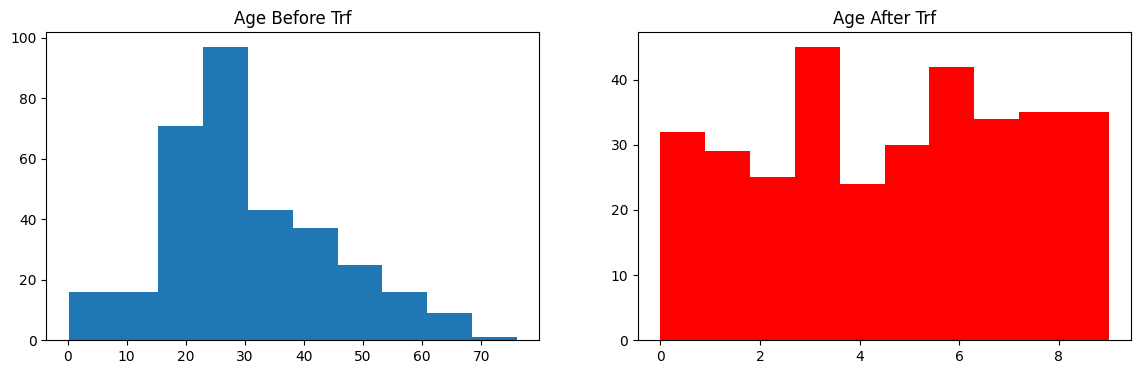

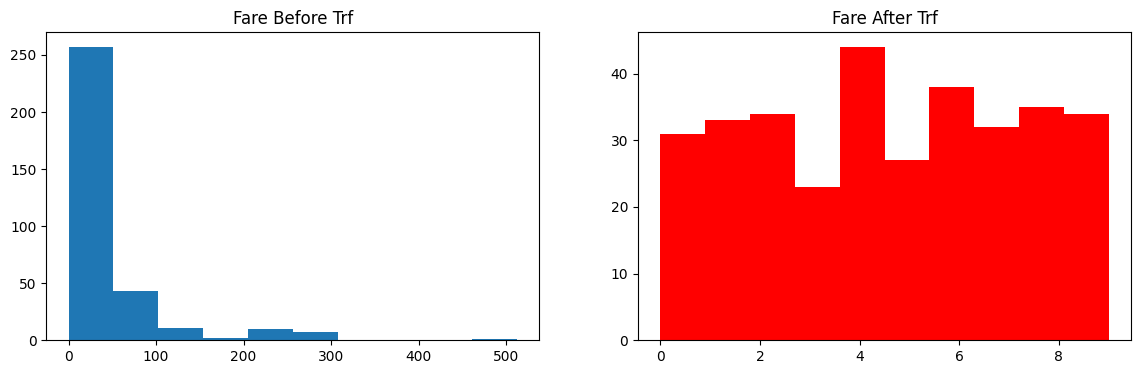

In [20]:
Discretizer(10,'quantile')

Accuracy using cross validation: 0.6255793226381462


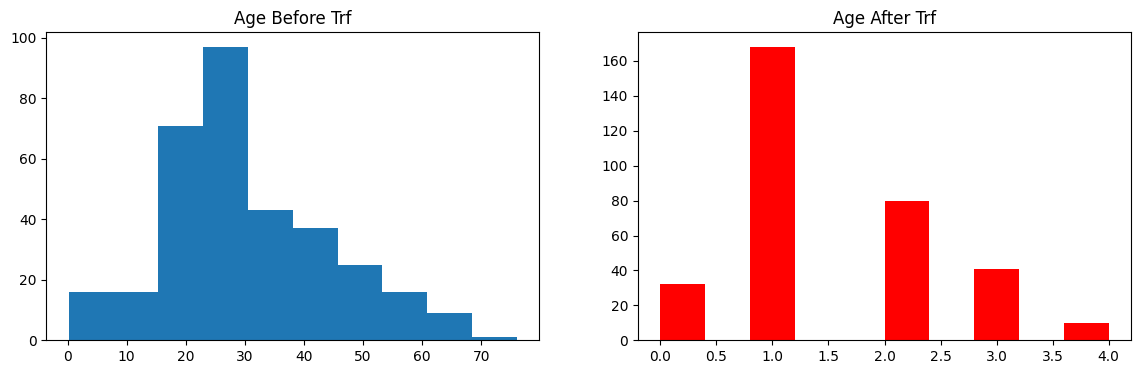

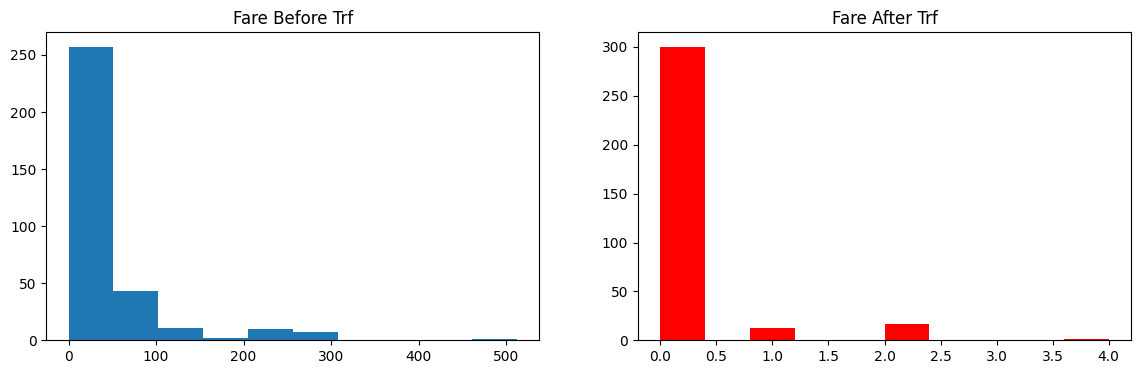

In [22]:
Discretizer(5,'uniform')

Accuracy using cross validation: 0.6223707664884136


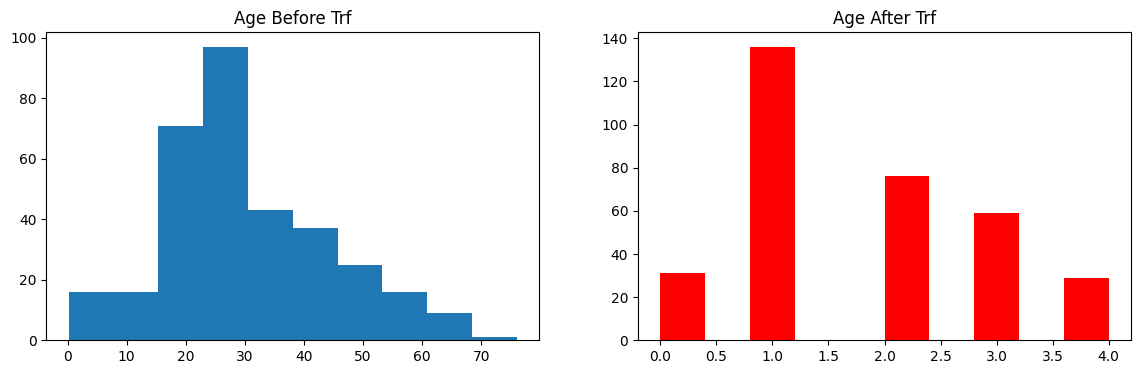

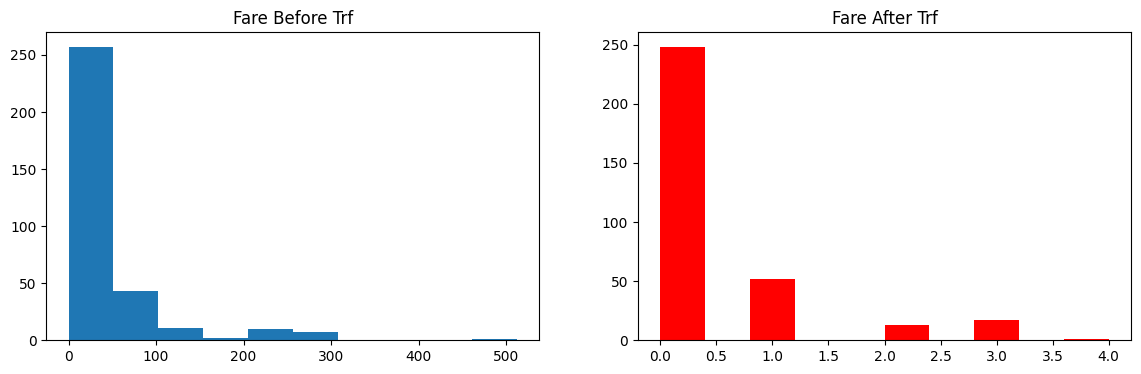

In [23]:
Discretizer(5,'kmeans')